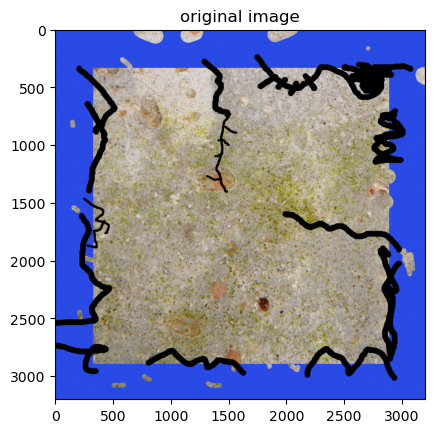

In [ ]:
#!/usr/bin/env python3

import os
import cv as cv
import matplotlib.pyplot as plt
import numpy as np

img_name = '/home/dtsai/Data/victis_datasets/3230-8-1-5-0-240118-1626_tab02_simulated_outsideedges_bluetray.jpg'
img = cv.imread(img_name)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(img)
plt.title('original image')

# the goal is to binarize this image to just get the coral tab stuff - the tray tab must be "blacked out"
plt.show()


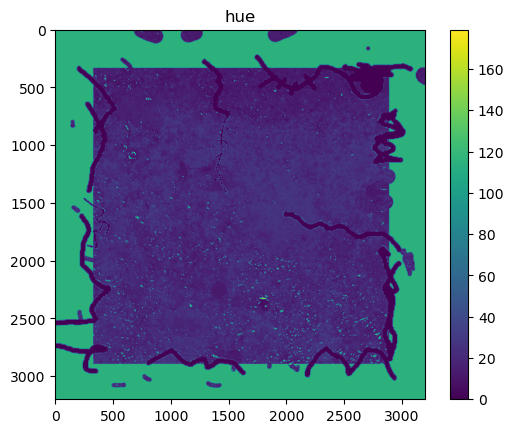

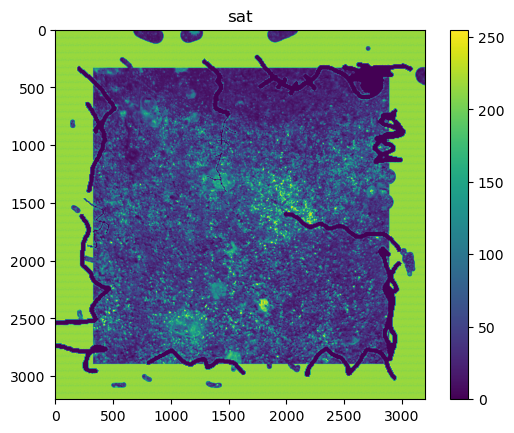

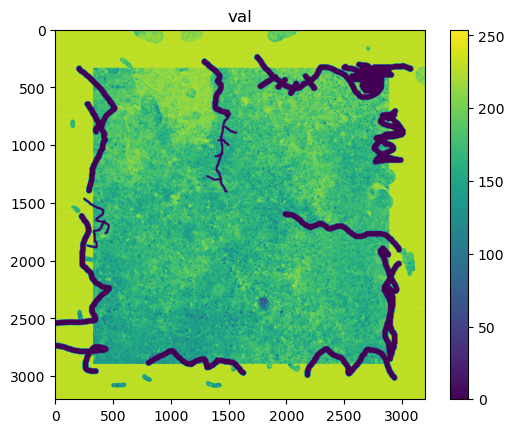

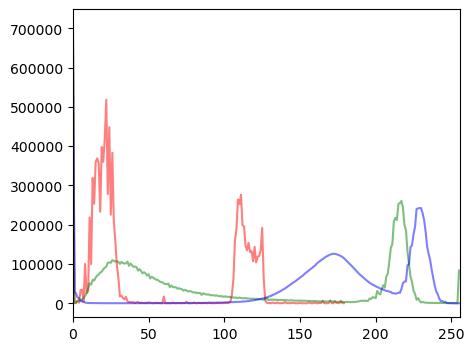

In [3]:
# could just do colour thresholding in HSV space

# convert image to HSV
# plot to show histograms for each channel
# choose/select threshold

img_hsv = cv.cvtColor(img, cv.COLOR_RGB2HSV)
h,s,v = cv.split(img_hsv)

plt.figure()
plt.imshow(h)
plt.colorbar()
plt.title('hue')
    
plt.figure()
plt.imshow(s)
plt.colorbar()
plt.title('sat')

plt.figure()
plt.imshow(v)
plt.colorbar()
plt.title('val')

# compute histograms
hist_h = cv.calcHist([h], [0], None, [180], (0, 180), accumulate=False)
hist_s = cv.calcHist([s], [0], None, [256], (0, 256))
hist_v = cv.calcHist([v], [0], None, [256], [0, 256])


# H = np.vstack((np.squeeze(hist_h), np.arange(0,180)))
# print(hist_h[179])

plt.figure(figsize=(5,4))
# plt.subplot(1,3,1)
plt.plot(hist_h, alpha=0.5, color='r', label='hue')
# plt.xlim([0, 180])

# plt.subplot(1,3,2)
plt.plot(hist_s, alpha=0.5, color='g', label='sat')
plt.xlim([0,256])

# plt.subplot(1,3,3)
plt.plot(hist_v, alpha=0.5, color='b', label='val')
plt.xlim([0,256])


# plt.hist(hist_s, alpha=0.5, color='g', label='sat')
# plt.hist(hist_v, alpha=0.5, color='b', label='val')
# 
plt.show()
# apply threshold
# make the other areas black for binary mask


- Hue (H): The type of color, ranging from 0° to 179° in OpenCV (as opposed to 0° to 360°).
- Saturation (S): Intensity or purity of the color, ranging from 0 to 255.
- Value (V): Brightness of the color, ranging from 0 to 255.


![alt text](gyuw4-2078904168.png)


In [ ]:
import ipywidgets as widgets
from ipywidgets import interact, VBox, HBox, Output

min_hue_value = None
max_hue_value = None
min_sat_value = None
max_sat_value = None
min_val_value = None
max_val_value = None

def display_thresholded_image(image, min_thresh, max_thresh, title="Threshold Display", subtitle="Adjust the sliders to see changes"):
    # Apply threshold
    mask = cv.inRange(image, min_thresh, max_thresh)
    
    # Convert to RGB with thresholded area in red
    colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    colored_mask[mask > 0] = [255, 0, 0]  # Red for thresholded area
    
    # Add black border
    bordered_image = cv.copyMakeBorder(colored_mask, 5, 5, 5, 5, cv.BORDER_CONSTANT, value=[0, 0, 0])
    
    # Display the image
    plt.figure(figsize=(10,10))
    plt.title(title)
    plt.suptitle(subtitle)
    plt.imshow(bordered_image)
    plt.axis('off')
    plt.show()

# Generate a sample 3-channel grayscale image
# image = np.random.randint(0, 256, (256, 256, 3), dtype=np.uint8)

def update_display(min_hue, max_hue, min_saturation, max_saturation, min_value, max_value):
    global min_hue_value, max_hue_value, min_sat_value, max_sat_value, min_val_value, max_val_value
    
    # Convert image to HSV
    # hsv_image = cv.cvtColor(image, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(img_hsv)
    
    # Apply thresholds
    mask_hue = cv.inRange(h, min_hue, max_hue)
    mask_saturation = cv.inRange(s, min_saturation, max_saturation)
    mask_value = cv.inRange(v, min_value, max_value)
    combined_mask = cv.bitwise_and(mask_hue, cv.bitwise_and(mask_saturation, mask_value))
    
    # TODO store current slider values as global variables
    min_hue_value = min_hue
    max_hue_value = max_hue
    min_sat_value = min_saturation
    max_sat_value = max_saturation
    min_val_value = min_value
    max_val_value = max_value
     
    # Convert masks to RGB for visualization
    def mask_to_rgb(mask):
        rgb_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
        rgb_mask[mask > 0] = [255, 0, 0]
        return cv.copyMakeBorder(rgb_mask, 5, 5, 5, 5, cv.BORDER_CONSTANT, value=[0, 0, 0])
    
    img_hue, img_saturation, img_value = mask_to_rgb(mask_hue), mask_to_rgb(mask_saturation), mask_to_rgb(mask_value)
    combined_img = mask_to_rgb(combined_mask)
    
    # Display images
    output.clear_output(wait=True)
    with output:
        fig, axes = plt.subplots(1, 4, figsize=(24, 12))
        axes[0].imshow(img_hue)
        axes[0].set_title("Hue Threshold")
        axes[0].axis("off")
        
        axes[1].imshow(img_saturation)
        axes[1].set_title("Saturation Threshold")
        axes[1].axis("off")
        
        axes[2].imshow(img_value)
        axes[2].set_title("Value Threshold")
        axes[2].axis("off")
        
        axes[3].imshow(combined_img)
        axes[3].set_title("AND Combination")
        axes[3].axis("off")
        
        plt.tight_layout()
        plt.show()

output = Output()
sliders = VBox([
    widgets.Label("Hue Thresholds"),
    HBox([
        widgets.IntSlider(min=0, max=180, step=1, value=50, description='Min Hue', layout=widgets.Layout(width='400px')),
        widgets.IntSlider(min=0, max=180, step=1, value=150, description='Max Hue', layout=widgets.Layout(width='400px'))
    ]),
    widgets.Label("Saturation Thresholds"),
    HBox([
        widgets.IntSlider(min=0, max=255, step=1, value=50, description='Min Sat', layout=widgets.Layout(width='400px')),
        widgets.IntSlider(min=0, max=255, step=1, value=200, description='Max Sat', layout=widgets.Layout(width='400px'))
    ]),
    widgets.Label("Value Thresholds"),
    HBox([
        widgets.IntSlider(min=0, max=255, step=1, value=50, description='Min Val', layout=widgets.Layout(width='400px')),
        widgets.IntSlider(min=0, max=255, step=1, value=200, description='Max Val', layout=widgets.Layout(width='400px'))
    ])
])

interact(update_display, 
         min_hue=sliders.children[1].children[0], 
         max_hue=sliders.children[1].children[1],
         min_saturation=sliders.children[3].children[0], 
         max_saturation=sliders.children[3].children[1],
         min_value=sliders.children[5].children[0], 
         max_value=sliders.children[5].children[1])

VBox([output])

# # Function to display the slider values
# def on_slider_change(change):
#     print(f"Min Hue: {min_hue_slider.value}, Max Hue: {max_hue_slider.value}")
#     print(f"Min Saturation: {min_saturation_slider.value}, Max Saturation: {max_saturation_slider.value}")
#     print(f"Min Value: {min_value_slider.value}, Max Value: {max_value_slider.value}")
    
# # Observe changes to the sliders
# min_hue_slider.observe(on_slider_change, names='value')
# max_hue_slider.observe(on_slider_change, names='value')
# min_saturation_slider.observe(on_slider_change, names='value')
# max_saturation_slider.observe(on_slider_change, names='value')
# min_value_slider.observe(on_slider_change, names='value')
# max_value_slider.observe(on_slider_change, names='value')

interactive(children=(IntSlider(value=50, description='Min Hue', layout=Layout(width='400px'), max=180), IntSl…

In [ ]:
# from widget above
min_hue_value = 90
max_hue_value = 132
min_sat_value = 190
max_sat_value = 255
min_val_value = 208
max_val_value = 255

print(min_hue_value)
# take hsv thresholds 

67
